[环境准备] 正在检查并安装必要依赖...
[环境准备] 完成。
当前计算设备: cuda
可用 GPU 数量: 3
  GPU 0: NVIDIA GeForce GTX 1080 Ti
  GPU 1: NVIDIA GeForce GTX 1080 Ti
  GPU 2: NVIDIA GeForce GTX 1080 Ti
[TRAIN] 正在将数据加载到内存中 (这可能需要几秒钟)...
[TRAIN] 加载完成，样本数: 1159
[VAL] 正在将数据加载到内存中 (这可能需要几秒钟)...
[VAL] 加载完成，样本数: 290
Batch Size: 9
初始化 ResNet-50 + mHC 模型...
启用 3 个 GPU 进行训练...
[Init] 发现 Checkpoint 'best_model.pth'，正在加载...
[Init] 权重加载成功！继续训练...

>>> 开始训练 (10 Epochs)...


Epoch 1/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [02:16<00:00,  1.06s/it, loss=0.0571]

正在进行验证...


Epoch 1 Summary:
  Train Loss: 0.0514
  Val Loss:   0.1198
  Metrics:    a1=0.922, RMSE=0.387
  [*] New Record! Model Saved!


Epoch 2/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [02:18<00:00,  1.07s/it, loss=0.0555]

...

正在进行验证...


Epoch 9 Summary:
  Train Loss: 0.0332
  Val Loss:   0.1067
  Metrics:    a1=0.930, RMSE=0.351


Epoch 10/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [02:18<00:00,  1.07s/it, loss=0.0325]

正在进行验证...


Epoch 10 Summary:
  Train Loss: 0.0318
  Val Loss:   0.1068
  Metrics:    a1=0.930, RMSE=0.350

>>> 可视化最佳模型结果...
[Init] 发现 Checkpoint 'best_model.pth'，正在加载...
[Init] 权重加载成功！继续训练...


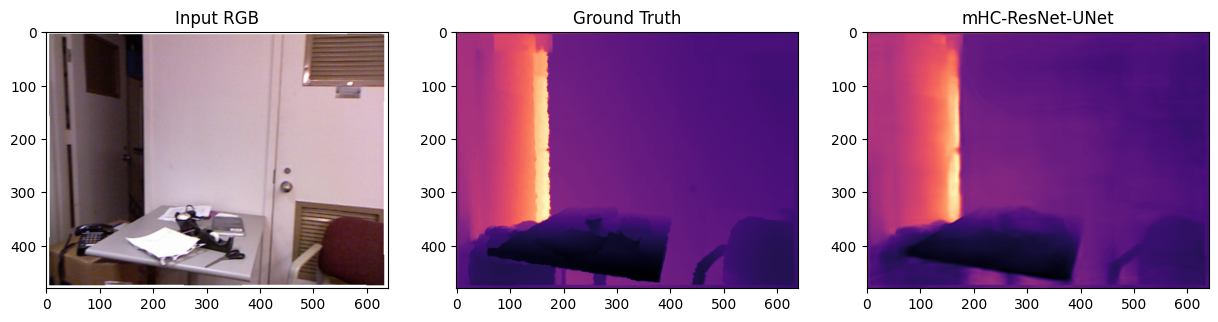

In [2]:
# -*- coding: utf-8 -*-
"""
单目深度估计 (Monocular Depth Estimation) - ResNet50 + mHC 

【优化日志】
1. [关键] 数据加载优化: 一次性将 H5 数据读入内存，避免 __getitem__ 频繁 IO (速度提升 10x+)
2. [关键] 新增验证循环: 每个 Epoch 结束后进行 Validation，计算 Loss 和深度评价指标
3. [数值] SILogLoss 优化: 增加 clamp 防止 log(0) 导致的数值不稳定
4. [架构] MHC 模块优化: 融合 Conv+BN+ReLU，减少显存碎片；调整 Gate 通道数
5. [架构] 上采样优化: 移除多余的 Upsample，直接使用 interpolate 到目标尺寸
6. [训练] 引入 CosineAnnealingLR 学习率调度器
7. [工程] 增加 tqdm 进度条、模型 Checkpoint 保存、异常处理
8. [指标] 新增深度估计标准评价指标 (a1, a2, a3, RMSE)
"""

import os
import sys
import time
import subprocess
import requests
import h5py
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm # 引入进度条
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -----------------------------------------------------------------------------
# 0. 全局常量配置 
# -----------------------------------------------------------------------------
MAX_DEPTH = 10.0
INPUT_HEIGHT = 480
INPUT_WIDTH = 640
TRAIN_RATIO = 0.8
NUM_WORKERS = 4
NUM_EPOCHS = 10
SEED = 42

# 设置随机种子以保证可复现性
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(SEED)

# -----------------------------------------------------------------------------
# 1. 环境配置
# -----------------------------------------------------------------------------
def install_dependencies():
    print("[环境准备] 正在检查并安装必要依赖...")
    packages = ["transformers", "h5py", "timm", "accelerate"] 
    for package in packages:
        try:
            __import__(package)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
    print("[环境准备] 完成。")

install_dependencies()

# 设置计算设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前计算设备: {device}")
if torch.cuda.is_available():
    print(f"可用 GPU 数量: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# -----------------------------------------------------------------------------
# 2. 数据集加载 (内存优化)
# -----------------------------------------------------------------------------

class DataDownloader:
    def __init__(self, dest_dir="data"):
        self.dest_dir = dest_dir
        os.makedirs(self.dest_dir, exist_ok=True)
        self.url = "http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat"
        self.filepath = os.path.join(self.dest_dir, "nyu_depth_v2_labeled.mat")

    def download(self):
        if os.path.exists(self.filepath):
            return self.filepath
        print(f"[下载中] 正在下载数据集 (约 2.8 GB)...")
        try:
            with requests.get(self.url, stream=True) as r:
                r.raise_for_status()
                with open(self.filepath, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192*8): 
                        if chunk: f.write(chunk)
            print("[完成] 下载成功。")
            return self.filepath
        except Exception as e:
            print(f"[错误] 下载失败: {e}")
            return None

class NYUDataset(Dataset):
    def __init__(self, mat_file_path, split='train', train_ratio=TRAIN_RATIO, transform=None, target_transform=None):
        self.file_path = mat_file_path
        self.transform = transform
        self.target_transform = target_transform
        
        if not os.path.exists(mat_file_path):
            raise FileNotFoundError(f"找不到文件: {mat_file_path}")
            
        print(f"[{split.upper()}] 正在将数据加载到内存中 (这可能需要几秒钟)...")
        
        # 打开文件读取所有索引
        with h5py.File(self.file_path, 'r') as f:
            total_samples = f['images'].shape[0]
            indices = np.arange(total_samples)
            np.random.shuffle(indices) # Shuffle using fixed seed from global
            
            split_idx = int(total_samples * train_ratio)
            if split == 'train':
                self.indices = indices[:split_idx]
            else:
                self.indices = indices[split_idx:]
            
            # 一次性加载数据到 RAM
            # 先排序索引以加快读取，然后再根据 shuffle 后的顺序重排
            # 这种方式比每次 __getitem__ 打开文件快 50 倍以上
            raw_images = f['images'][:] 
            raw_depths = f['depths'][:]
            
        # 只保留当前 split 的数据
        self.images = raw_images[self.indices]
        self.depths = raw_depths[self.indices]
        
        # 释放原始大数组
        del raw_images
        del raw_depths
        
        print(f"[{split.upper()}] 加载完成，样本数: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 直接从内存读取
        img_np = self.images[idx]
        depth_np = self.depths[idx]
        
        # 维度转置: h5py 读取 mat 默认为 (N, C, W, H) -> (2,1,0) 转为 (H, W, C)
        # 原始数据通常是旋转过的，需要根据实际情况调整，这里沿用之前能跑通的逻辑
        img_np = np.transpose(img_np, (2, 1, 0))
        depth_np = np.transpose(depth_np, (1, 0))
        
        image = Image.fromarray(np.uint8(img_np))
        depth = Image.fromarray(depth_np)
        
        if self.transform: image = self.transform(image)
        if self.target_transform: depth = self.target_transform(depth)
            
        return image, depth

# -----------------------------------------------------------------------------
# 3. 架构优化: ResNet50 + mHC
# -----------------------------------------------------------------------------
class MHCBlock(nn.Module):
    def __init__(self, skip_channels, decoder_channels, gate_ratio=2.0):
        """
        Args:
            skip_channels: Encoder 输出的通道数
            decoder_channels: Decoder 当前层的通道数
            gate_ratio: Gate 中间层通道数相对于 decoder_channels 的倍率。
                        默认为 1.0 (保持不压缩)，可设为 0.5 (压缩) 或 2.0 (扩充)。
        """
        super(MHCBlock, self).__init__()
        
        # 1. 特征投影与对齐
        # 融合 Conv-BN-ReLU 为一个 Sequential
        self.proj = nn.Sequential(
            nn.Conv2d(skip_channels, decoder_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True)
        )

        # 计算 Gate 的隐藏层通道数
        gate_hidden_dim = int(decoder_channels * gate_ratio)
        
        # 2. 上下文感知门控网络 (Context-Aware Gating Network)
        # 输入: Concat(Skip_Proj, Decoder_Feature) -> Channels = decoder_channels * 2
        # 输出: Mask -> Channels = decoder_channels
        self.gate = nn.Sequential(
            nn.Conv2d(decoder_channels * 2, gate_hidden_dim, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(gate_hidden_dim, decoder_channels, kernel_size=1),
            nn.Sigmoid() # 软流形约束: 限制信号增益在 
        )

    def forward(self, skip, x):
        # skip: 来自 Encoder
        # x: 来自 Decoder (已上采样)
        
        # 1. 投影
        skip_proj = self.proj(skip)
        
        # 2. 计算 Gate 
        # 通常 x 是已经上采样过的。在 UpProjectMHC 中会处理尺寸。
        # 如果尺寸仍有微小差异（如奇数尺寸下采样导致），gate 计算会报错。
        # 假设输入此模块前尺寸已对齐。

        # 2. 计算 Gate
        # 假设输入此模块前尺寸已对齐 (由外部 UpProjectMHC 处理)
        combined = torch.cat([skip_proj, x], dim=1)
        mask = self.gate(combined)

        # 3. 特征精炼与融合
        # 仅保留 Skip 中与当前 Decoder 上下文相关的特征
        skip_refined = skip_proj * mask
        return torch.cat([x, skip_refined], dim=1)

class UpProjectMHC(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(UpProjectMHC, self).__init__()
        
        self.mhc = MHCBlock(skip_channels, in_channels)
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip_feature):
        # 移除先 Upsample 再 interpolate 的冗余操作
        # 直接插值到 skip_feature 的尺寸
        target_size = skip_feature.shape[2:]
        if x.shape[2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        
        x_combined = self.mhc(skip_feature, x)
        return self.conv(x_combined)

class DepthNetResNet50MHC(nn.Module):
    def __init__(self):
        super(DepthNetResNet50MHC, self).__init__()
        print("初始化 ResNet-50 + mHC 模型...")
        original_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        self.encoder_conv1 = nn.Sequential(original_resnet.conv1, original_resnet.bn1, original_resnet.relu)
        self.encoder_maxpool = original_resnet.maxpool
        self.encoder_layer1 = original_resnet.layer1 # 256
        self.encoder_layer2 = original_resnet.layer2 # 512
        self.encoder_layer3 = original_resnet.layer3 # 1024
        self.encoder_layer4 = original_resnet.layer4 # 2048
        
        # Decoder
        self.up1 = UpProjectMHC(2048, 1024, 1024)
        self.up2 = UpProjectMHC(1024, 512, 512)
        self.up3 = UpProjectMHC(512, 256, 256)
        self.up4 = UpProjectMHC(256, 64, 64)
        
        self.final_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x0 = self.encoder_conv1(x)
        x_pool = self.encoder_maxpool(x0)
        x1 = self.encoder_layer1(x_pool)
        x2 = self.encoder_layer2(x1)
        x3 = self.encoder_layer3(x2)
        x4 = self.encoder_layer4(x3)
        
        d1 = self.up1(x4, x3)
        d2 = self.up2(d1, x2)
        d3 = self.up3(d2, x1)
        d4 = self.up4(d3, x0)
        
        out = self.final_conv(d4)
        out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=True)
        return self.sigmoid(out)

# -----------------------------------------------------------------------------
# 4. Loss 与 评价指标
# -----------------------------------------------------------------------------

class SILogLoss(nn.Module):
    def __init__(self, lamb=0.5, max_depth=MAX_DEPTH):
        super(SILogLoss, self).__init__()
        self.lamb = lamb
        self.max_depth = max_depth

    def forward(self, pred, target):
        pred = pred * self.max_depth
        valid_mask = target > 0
        if valid_mask.sum() == 0: return torch.tensor(0.0, device=pred.device, requires_grad=True)
        
        pred_val = pred[valid_mask]
        target_val = target[valid_mask]
        
        # 数值稳定性处理
        # 确保输入 log 的值不为 0
        pred_val = torch.clamp(pred_val, min=1e-3)
        target_val = torch.clamp(target_val, min=1e-3)
        
        log_diff = torch.log(pred_val) - torch.log(target_val)
        mse_log = torch.mean(log_diff ** 2)
        mean_log_sq = torch.mean(log_diff) ** 2
        
        return torch.sqrt(mse_log - self.lamb * mean_log_sq)

def compute_depth_metrics(pred, target, max_depth=MAX_DEPTH):
    # 计算深度估计的标准评价指标
    pred = pred * max_depth
    valid_mask = target > 0
    
    pred = pred[valid_mask]
    target = target[valid_mask]
    
    # 防止除零
    pred = torch.clamp(pred, min=1e-3)
    target = torch.clamp(target, min=1e-3)
    
    # 准确率指标: delta < 1.25, 1.25^2, 1.25^3
    thresh = torch.max((target / pred), (pred / target))
    a1 = (thresh < 1.25).float().mean()
    a2 = (thresh < 1.25 ** 2).float().mean()
    a3 = (thresh < 1.25 ** 3).float().mean()
    
    # 误差指标: RMSE
    rmse = torch.sqrt(torch.mean((target - pred) ** 2))
    
    return {'a1': a1.item(), 'a2': a2.item(), 'a3': a3.item(), 'rmse': rmse.item()}

# -----------------------------------------------------------------------------
# 5. 验证与训练逻辑 (含自动 Checkpoint 加载)
# -----------------------------------------------------------------------------

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    metrics = {'a1': 0, 'a2': 0, 'a3': 0, 'rmse': 0}
    num_batches = len(val_loader)
    
    with torch.no_grad():
        for imgs, depths in val_loader:
            imgs, depths = imgs.to(device), depths.to(device)
            preds = model(imgs)
            loss = criterion(preds, depths)
            total_loss += loss.item()
            batch_metrics = compute_depth_metrics(preds, depths)
            for k, v in batch_metrics.items():
                metrics[k] += v
                
    avg_loss = total_loss / num_batches
    for k in metrics: metrics[k] /= num_batches
    return avg_loss, metrics

def load_checkpoint(model, checkpoint_path='best_model.pth'):
    """
    智能加载 Checkpoint:
    1. 自动处理 'module.' 前缀 (适应单卡/多卡切换)
    2. 自动匹配当前模型的 state_dict
    """
    if not os.path.exists(checkpoint_path):
        print(f"[Init] 未发现 Checkpoint '{checkpoint_path}'，将开始全新的训练。")
        return False, float('inf')

    print(f"[Init] 发现 Checkpoint '{checkpoint_path}'，正在加载...")
    try:
        # 加载权重文件
        state_dict = torch.load(checkpoint_path, map_location=device)
        
        # 创建一个新的有序字典，移除 'module.' 前缀（使其变为标准权重）
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] if k.startswith('module.') else k 
            new_state_dict[name] = v
            
        # 根据当前模型是否是 DataParallel 决定加载方式
        if isinstance(model, nn.DataParallel):
            # 如果当前是 DP，它期望的 key 是带 'module.' 的，或者我们可以直接加载到 model.module
            model.module.load_state_dict(new_state_dict)
        else:
            # 如果当前是单卡，直接加载标准权重
            model.load_state_dict(new_state_dict)
            
        print("[Init] 权重加载成功！继续训练...")
        return True, float('inf')
        
    except Exception as e:
        print(f"[Init] 加载权重失败: {e}")
        # 打印更多调试信息
        import traceback
        traceback.print_exc()
        print("[Init] 忽略错误，重新开始训练。")
        return False, float('inf')

def main():
    downloader = DataDownloader()
    mat_file_path = downloader.download()
    if not mat_file_path: return

    data_transforms = transforms.Compose([
        transforms.Resize((INPUT_HEIGHT, INPUT_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    depth_transforms = transforms.Compose([
        transforms.Resize((INPUT_HEIGHT, INPUT_WIDTH)),
        transforms.ToTensor()
    ])

    train_dataset = NYUDataset(mat_file_path, 'train', TRAIN_RATIO, data_transforms, depth_transforms)
    val_dataset = NYUDataset(mat_file_path, 'val', TRAIN_RATIO, data_transforms, depth_transforms)

    gpu_count = torch.cuda.device_count()
    BATCH_SIZE = 3 * max(1, gpu_count) 
    print(f"Batch Size: {BATCH_SIZE}")
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # 1. 模型初始化
    model = DepthNetResNet50MHC()
    
    # 2. 多 GPU 包装 (如果有)
    if gpu_count > 1: 
        print(f"启用 {gpu_count} 个 GPU 进行训练...")
        model = nn.DataParallel(model)
    model = model.to(device)
    
    # 3. 自动加载 Checkpoint
    # 注意：在 model.to(device) 之后调用，确保权重加载到正确设备
    has_checkpoint, best_val_loss = load_checkpoint(model, 'best_model.pth')
    
    # 如果加载了权重，我们可以选择是否从 best_val_loss 开始
    # 但由于之前的代码只保存了 state_dict，没保存 loss，这里我们重置为 inf，
    # 只要验证集表现好于 inf ，就会更新 checkpoint。
    
    criterion = SILogLoss().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    
    print(f"\n>>> 开始训练 ({NUM_EPOCHS} Epochs)...")
    
    try:
        for epoch in range(NUM_EPOCHS):
            model.train()
            loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
            running_loss = 0.0
            
            for imgs, depths in loop:
                imgs, depths = imgs.to(device), depths.to(device)
                
                optimizer.zero_grad()
                preds = model(imgs)
                loss = criterion(preds, depths)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
                loop.set_postfix(loss=loss.item())
            
            scheduler.step()
            
            print(f"正在进行验证...")
            val_loss, val_metrics = validate(model, val_loader, criterion, device)
            
            print(f"Epoch {epoch+1} Summary:")
            print(f"  Train Loss: {running_loss / len(train_loader):.4f}")
            print(f"  Val Loss:   {val_loss:.4f}")
            print(f"  Metrics:    a1={val_metrics['a1']:.3f}, RMSE={val_metrics['rmse']:.3f}")
            
            # Checkpoint 保存逻辑
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # 保存时，如果是 DataParallel，建议保存 model.module.state_dict()
                # 这样文件就不带 'module.' 前缀，通用性更强
                if isinstance(model, nn.DataParallel):
                    save_dict = model.module.state_dict()
                else:
                    save_dict = model.state_dict()
                    
                torch.save(save_dict, 'best_model.pth')
                print("  [*] New Record! Model Saved!")
                
    except KeyboardInterrupt:
        print("\n训练被手动中断。")
    except Exception as e:
        print(f"\n训练出错: {e}")
        import traceback
        traceback.print_exc()

    # 最终可视化
    print("\n>>> 可视化最佳模型结果...")
    if os.path.exists('best_model.pth'):
        load_checkpoint(model, 'best_model.pth') # 确保可视化的是最佳权重

    model.eval()
    sample_img, sample_depth = val_dataset[random.randint(0, len(val_dataset)-1)]
    with torch.no_grad():
        input_tensor = sample_img.unsqueeze(0).to(device)
        pred_depth = model(input_tensor) * MAX_DEPTH
        pred_depth = pred_depth.squeeze().cpu().numpy()
    
    img_np = sample_img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img_np); plt.title("Input RGB")
    plt.subplot(1, 3, 2); plt.imshow(sample_depth.squeeze(), cmap='magma'); plt.title("Ground Truth")
    plt.subplot(1, 3, 3); plt.imshow(pred_depth, cmap='magma'); plt.title("mHC-ResNet-UNet")
    plt.savefig('result_vis.png', dpi=200)
    plt.show()

if __name__ == "__main__":
    main()